In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load data

In [2]:
adata_sc = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE.h5ad")
adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

/scratch/fast/66059/ipykernel_2746922/2211780948.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


In [3]:
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 

adata_sc.raw = adata_sc.copy()
sc.pp.log1p(adata_sc)
sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000, inplace=True)
hvg_genes = adata_sc.var_names[adata_sc.var['highly_variable']].tolist()
genes_to_keep = list(set(hvg_genes) | set(adata_mer.var_names.tolist()))

raw_adata = adata_sc.raw.to_adata()
new_adata = raw_adata[:, genes_to_keep].copy()
adata_sc = new_adata.copy()

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


# batch correct

In [4]:
import scvi 

In [5]:

scvi.settings.seed = 1

scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sample_name', categorical_covariate_keys= ['sex',])
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=10, gene_likelihood="zinb")
model.train()

[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [6]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [7]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15)
sc.tl.leiden(adata_sc,resolution = .5,random_state=210)
sc.tl.umap(adata_sc,random_state=210)


/scratch/fast/66059/ipykernel_2746922/234665908.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sc,resolution = .5,random_state=210)


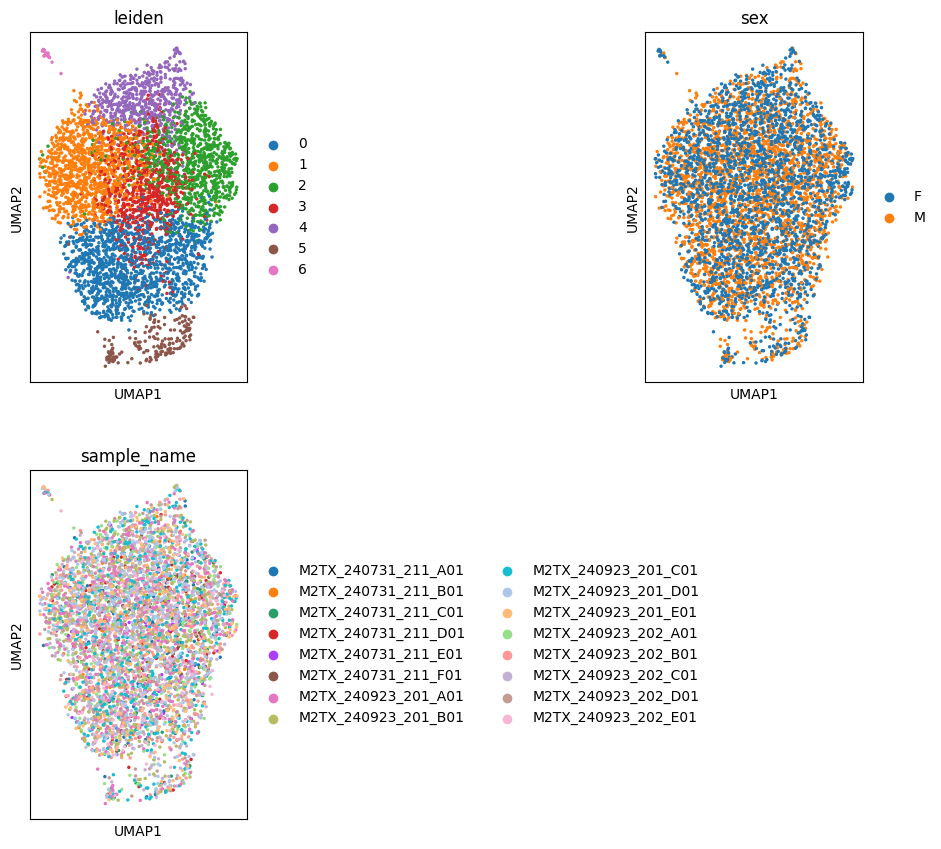

In [8]:
ax = sc.pl.umap(
    adata_sc,color=["leiden", "sex",'sample_name'],ncols=2,show = False)
for a in ax:
    a.set_aspect('equal')

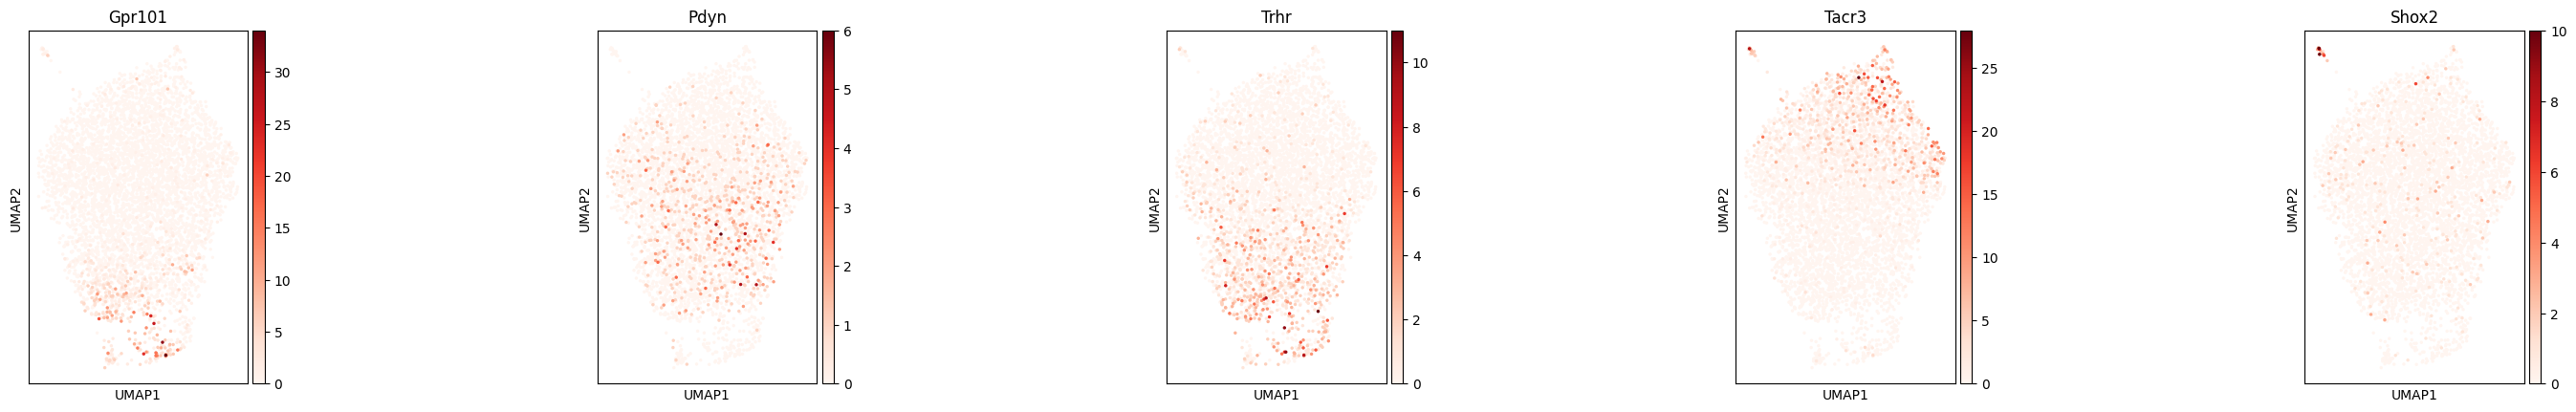

In [9]:
ax = sc.pl.umap(adata_sc,color=intersted_genes,ncols=5,show = False, cmap = 'Reds')
for a in ax:
    a.set_aspect('equal')

# load merfish 

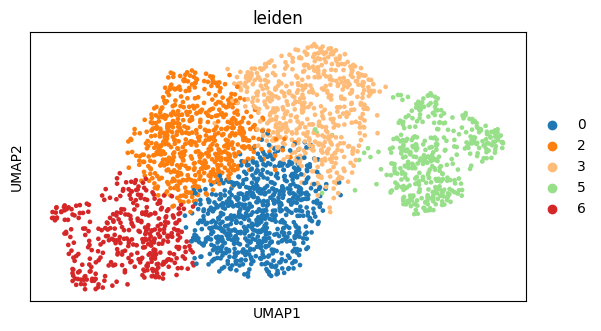

In [10]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

a = sc.pl.umap(adata_mer, color='leiden', show = False)
a.set_aspect('equal')

In [11]:
adata_mer.shape

(2651, 314)

**original code to run the imputations**
```
adata_mer_imputed = impute_mer_data(adata_sc, adata_mer, k=200, n_hvg=None)

```

In [12]:
import sys
sys.path.append('../func/')
from imputations import *

In [13]:
import pickle 
arc_info = pickle.load(open('/home/shuonan.chen/scratch_shuonan/LC_scRNAseq/arc_info.pkl', 'rb'))
locals().update(arc_info)

inverse_order = np.argsort(sort_indices)
t_projections_original_order = t_projections[inverse_order]


In [14]:
union_genes = np.union1d(adata_sc.var_names, adata_mer.var_names)  # > n_hvg
union_genes.shape

(2187,)

In [15]:
common_genes = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
print(common_genes.shape)
adata_sc_ref = adata_sc[:, common_genes].copy()  # we will impute based on this guy, number of `union_genes=2184` will be imputed. 


(314,)


In [16]:
k = 1

X_sc = adata_sc_ref[:, common_genes].X
X_mer = adata_mer[:, common_genes].X     

X_sc_norm = normalize_cols(X_sc, ranked=True)
X_mer_norm = normalize_cols(X_mer, ranked=True)


nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_sc_norm)
distances, indices = nbrs.kneighbors(X_mer_norm) # distance: size (N_mer, K)

epsilon = 1e-10
weights = 1 / (distances + epsilon)
weights = weights / weights.sum(axis=1, keepdims=True)  # normalize so that weights sum to 1



In [17]:
imputed_t_loc = np.zeros((adata_mer.n_obs))
for i in range(adata_mer.n_obs):
    neighbor_idx = indices[i]    
    imputed_t_loc[i] = np.dot(weights[i], t_projections_original_order[neighbor_idx])

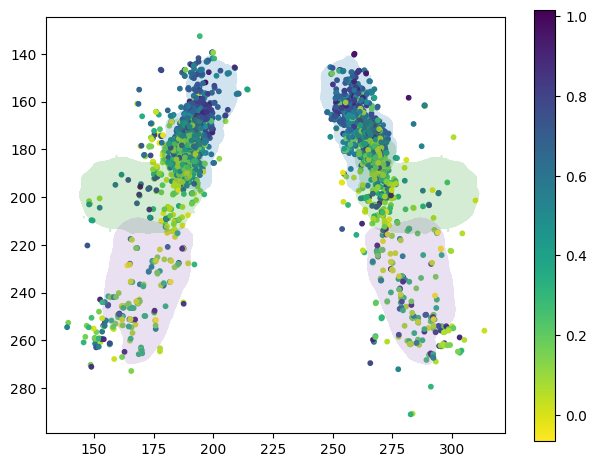

In [18]:
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
            s = 10, c = imputed_t_loc, cmap = 'viridis_r')#, 
#             edgecolor = 'k', linewidth = .3)
plt.colorbar()
plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')
plt.tight_layout()

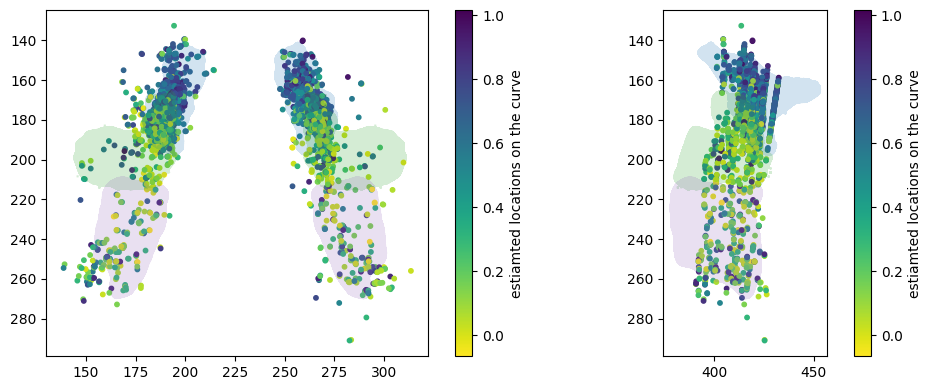

In [19]:
plt.figure(figsize= (10,4))
plt.subplot(1,2,1)
sca=plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
            s = 10, c = imputed_t_loc, cmap = 'viridis_r')
cbar = plt.colorbar(sca)
cbar.set_label('estiamted locations on the curve', loc='center')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')
plt.tight_layout()


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:,0],adata_mer.obsm['spatial'][:,1], 
            s = 10, c = imputed_t_loc, cmap = 'viridis_r')
cbar = plt.colorbar(sca)
cbar.set_label('estiamted locations on the curve', loc='center')

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')
plt.tight_layout()

In [ ]:



fig, ax = plt.subplots(figsize=(9, 6))
sca = ax.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
           s=5, alpha=0.8, c = imputed_t_loc, cmap = 'viridis_r')
cbar = fig.colorbar(sca)#,shrink=0.8, pad=0.04)
cbar.set_label('estiamted locations on the curve', loc='center')
ax.set_aspect('equal')
ax.set_xlabel('CCFv3 (M-L) (μm)')
ax.set_ylabel('CCFv3 (D-V) (μm)')
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(format_ticklabels(xticks))
ax.set_yticklabels(format_ticklabels(yticks))

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = xlim[0] + 0.1 * (xlim[1] - xlim[0])
y0 = ylim[0] + 0.05 * (ylim[1] - ylim[0])
ax.plot([x0, x0 + 40], [y0, y0], color='black', linewidth=4)
ax.text(x0 + 20, y0 - 3, f'{40 * 25 * 0.001:.1f} mm', ha='center', va='bottom', color='black')

plt.tight_layout()

In [74]:



fig, ax = plt.subplots(figsize=(9, 6))
sca = ax.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1], 
           s=5, alpha=0.8, c = imputed_t_loc, cmap = 'viridis_r')
cbar = fig.colorbar(sca)#,shrink=0.8, pad=0.04)
cbar.set_label('estiamted locations on the curve', loc='center')
ax.set_aspect('equal')
ax.set_xlabel('CCFv3 (M-L) (μm)')
ax.set_ylabel('CCFv3 (D-V) (μm)')
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(format_ticklabels(xticks))
ax.set_yticklabels(format_ticklabels(yticks))

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = xlim[0] + 0.1 * (xlim[1] - xlim[0])
y0 = ylim[0] + 0.05 * (ylim[1] - ylim[0])
ax.plot([x0, x0 + 40], [y0, y0], color='black', linewidth=4)
ax.text(x0 + 20, y0 - 3, f'{40 * 25 * 0.001:.1f} mm', ha='center', va='bottom', color='black')

plt.tight_layout()

((np.float64(129.96843132307637), np.float64(322.2499432704813)),
 (np.float64(298.93378456794653), np.float64(124.66360558794116)))

# saving these figs 

In [70]:
import os 

export_folder='/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/result_pngs/high_rez_figs/'
export_file_name = 'arcloc_imputed_coronal'

def format_ticklabels(ticks, scale=25):
    return [f'{int(t * scale)}' if i % 2 == 0 else '' for i, t in enumerate(ticks)]



fig, ax = plt.subplots(figsize=(9, 6))
sca = ax.scatter(adata_mer.obsm['spatial'][:,0],adata_mer.obsm['spatial'][:,1], 
           s=5, alpha=0.8, c = imputed_t_loc, cmap = 'viridis_r')
cbar = fig.colorbar(sca)#,shrink=0.8, pad=0.04)
cbar.set_label('estiamted locations on the curve', loc='center')
ax.set_aspect('equal')
ax.set_xlabel('CCFv3 (M-L) (μm)')
ax.set_ylabel('CCFv3 (D-V) (μm)')
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(format_ticklabels(xticks))
ax.set_yticklabels(format_ticklabels(yticks))

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = xlim[0] + 0.1 * (xlim[1] - xlim[0])
y0 = ylim[0] + 0.05 * (ylim[1] - ylim[0])
ax.plot([x0, x0 + 40], [y0, y0], color='black', linewidth=4)
ax.text(x0 + 20, y0 - 3, f'{40 * 25 * 0.001:.1f} mm', ha='center', va='bottom', color='black')

plt.tight_layout()

png_path = os.path.join(export_folder, f"{export_file_name}.png")
pdf_path = os.path.join(export_folder, f"{export_file_name}.pdf")

plt.savefig(png_path, dpi=400, bbox_inches='tight')
plt.savefig(pdf_path, dpi=400, bbox_inches='tight')
plt.close()


In [71]:
export_folder='/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/result_pngs/high_rez_figs/'
export_file_name = 'arcloc_imputed_sagital'

fig, ax = plt.subplots(figsize=(6, 6))
sca = ax.scatter(adata_mer.obsm['spatial'][:,0],adata_mer.obsm['spatial'][:,1], 
           s=5, alpha=0.8, c = imputed_t_loc, cmap = 'viridis_r')
cbar = fig.colorbar(sca)#,shrink=0.8, pad=0.04)
cbar.set_label('estiamted locations on the curve', loc='center')
ax.set_aspect('equal')
ax.set_xlabel('CCFv3 (A-P) (μm)')
ax.set_ylabel('CCFv3 (D-V) (μm)')
xticks = ax.get_xticks()
yticks = ax.get_yticks()
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(format_ticklabels(xticks))
ax.set_yticklabels(format_ticklabels(yticks))

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = xlim[0] + 0.1 * (xlim[1] - xlim[0])
y0 = ylim[0] + 0.05 * (ylim[1] - ylim[0])
ax.plot([x0, x0 + 40], [y0, y0], color='black', linewidth=4)
ax.text(x0 + 20, y0 - 3, f'{40 * 25 * 0.001:.1f} mm', ha='center', va='bottom', color='black')

plt.tight_layout()
png_path = os.path.join(export_folder, f"{export_file_name}.png")
pdf_path = os.path.join(export_folder, f"{export_file_name}.pdf")
plt.savefig(png_path, dpi=400, bbox_inches='tight')
plt.savefig(pdf_path, dpi=400, bbox_inches='tight')
plt.close()
